## Library Import

In [242]:
from tqdm import tqdm # progress bar

import pandas as pd
import numpy as np
import cv2
import os     # import os to accsses folders
import matplotlib.pyplot as plt
import seaborn as sns

# scaling and splitting
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# models
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression

# evaluation ----
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,roc_curve, roc_auc_score, auc
from sklearn.decomposition import PCA

# **1- DATA EXPLORATION**

In [269]:
# reading dataset paths
dataset_path = r"C:\Users\dohah\Documents\Projects\Detecting Malaria Model\MachineLearningProject\img_dataset"

Parasitized_path = os.path.join(dataset_path, 'Parasitized')
Uninfected_path = os.path.join(dataset_path, 'Uninfected')

In [270]:
# delete
# def load_images_optimized(folder_path, label, target_size=(64,64)):
#     images = []
#     labels = []
#     count = 0
#     for root, dirs, files in os.walk(folder_path):
#         for filename in tqdm(files, desc=f"Loading {folder_path}"):
            
#             # Skip non-images
#             if not (filename.lower().endswith(".png") or filename.lower().endswith(".jpg") or filename.lower().endswith(".jpeg")):
#                 continue
#             img_path = os.path.join(root, filename)
#             img = cv2.imread(img_path)
#             if img is None:
#                 continue
#             # Resize
#             img = cv2.resize(img, target_size)
#             # Convert to grayscale
#             img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#             # --- New Step: Edge Detection ---          need to understand
#             # Example using Canny: Adjust thresholds as needed (100, 200 are common starting points)
#             img = cv2.Canny(img, threshold1=100, threshold2=200)

#             # Normalize [0,1]
#             img = img.astype('float32') / 255.0

#             images.append(img)
#             labels.append(label)
#             count += 1
#     return images, labels, count

# # Load images
# parasitized_images, parasitized_labels, count_p = load_images_optimized(Parasitized_path, 1)
# uninfected_images, uninfected_labels, count_u = load_images_optimized(Uninfected_path, 0)

# # Combine images and labels
# images = parasitized_images + uninfected_images
# labels = parasitized_labels + uninfected_labels

# print(f"Parasitized images loaded: {count_p}")
# print(f"Uninfected images loaded: {count_u}")
# print(f"Total images loaded: {len(images)}")

In [271]:
# loading images without any processing
def load_images_simple(folder_path, label):
    images = [] # list to store images
    labels = [] # list to store labels
    count = 0 # counter for images

    for root, dirs, files in os.walk(folder_path): # root: current directory, dirs: subdirectories, files: files in current directory(images)
        for filename in tqdm(files, desc=f"Loading {folder_path}"): #--need a look    # tqdm for progress bar means showing progress of loading images 
            if not filename.lower().endswith((".png", ".jpg", ".jpeg")): # skip non-images
                continue
            img_path = os.path.join(root, filename)
            img = cv2.imread(img_path,1)    # color mode -> 1 , grayscale -> 0 , unchanged -> -1
            if img is None:
                continue

            images.append(img)
            labels.append(label)
            count += 1

    return images, labels, count

In [272]:
# load images
parasitized_images, parasitized_labels, count_p = load_images_simple(Parasitized_path, 1)
uninfected_images, uninfected_labels, count_u = load_images_simple(Uninfected_path, 0)

# images count
print("Parasitized images loaded: ",count_p)
print("Uninfected images loaded: ",count_u)
print("Total images loaded: ",count_p + count_u)


Loading C:\Users\dohah\Documents\Projects\Detecting Malaria Model\MachineLearningProject\img_dataset\Parasitized: 100%|██████████| 9955/9955 [01:30<00:00, 110.17it/s]
Loading C:\Users\dohah\Documents\Projects\Detecting Malaria Model\MachineLearningProject\img_dataset\Uninfected: 100%|██████████| 9955/9955 [00:09<00:00, 1040.00it/s]

Parasitized images loaded:  9954
Uninfected images loaded:  9954
Total images loaded:  19908


# **2- DATA PREPROCESSING**

In [273]:
# preprocessing function
def img_preprocessing(images , target_size = (64,64)):
    processed = []    # list to store processed images, if we append on "images" it will modify the original images
    for img in images:
        img_resized = cv2.resize(img, target_size)                    # resize           ---  64x64   -the reason of 64: reduce computational load while retaining
        img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)      # convert to gray  ---  3 channels -> 1 channel
        img_norm = img_gray.astype('float32') / 255.0                 # normalization    ---  by making pixel from [0,255] to [0,1]
        img_flat = img_norm.flatten()                                 # flatten          ---  from 2D to 1D array
        processed.append(img_flat)
    return processed

In [274]:
# preprocessing -> resize, grayscale, normalize, flatten
parasitized_images = img_preprocessing(parasitized_images)
uninfected_images = img_preprocessing(uninfected_images)

processed_images = parasitized_images + uninfected_images

In [275]:
# convert to numpy arrays     so we can use them in models
X = np.array(processed_images)     # for Kmeans and the features for Logistic Regression
y = np.array(parasitized_labels + uninfected_labels)   # labels for Logistic Regression 

In [276]:
# for K-means:

In [277]:
# feature scaling for K-means
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [278]:
print("X shape:",X.shape)
print("y shape:",y.shape)

X shape: (19908, 4096)
y shape: (19908,)


In [279]:
# for LR:

In [280]:
# split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y   #need a look   # to maintain the proportion of classes in both train and test sets
)

In [281]:
# feature scaling for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **3- MODEL TRAINING**

## 3.a- K-MEANS MODEL

In [282]:
# K-means

kmeans = KMeans(n_clusters=2, random_state=12)
labels = kmeans.fit_predict(X)

print(labels[:20])

[1 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 1 0 0 0]


In [283]:
# don't know what is that but seems like accuracy measure for unsupervised model
# need a look
from sklearn.metrics import silhouette_score

score = silhouette_score(X, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.20474256575107574


## 3.b- LOGISTIC REGRESSION MODEL

In [289]:
# after scaling the accuuracy looks bad --asking--
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

C:\Users\dohah\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [290]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy on test set: ",acc)

Accuracy on test set:  0.6007031642390759


# **4- EVALUATION**

In [291]:
# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

Classification Report:
              precision    recall  f1-score   support

           0     0.5988    0.6102    0.6045      1991
           1     0.6027    0.5912    0.5969      1991

    accuracy                         0.6007      3982
   macro avg     0.6007    0.6007    0.6007      3982
weighted avg     0.6007    0.6007    0.6007      3982



## Graphs for LR

##### **Confusion Matrix**

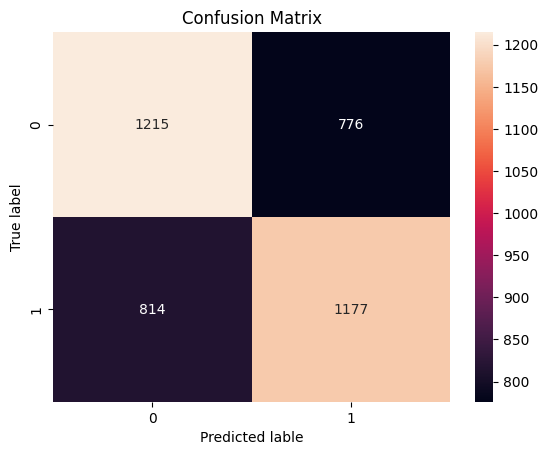

In [292]:
# see whats wrong
cm = confusion_matrix(y_test, y_pred)  

cm_df = pd.DataFrame(cm,
                     index= [0,1],
                     columns= [0,1])

sns.heatmap(cm_df, fmt='d', annot= True) # fmt='d' -> d means integer nombers will show
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted lable')
plt.show()


##### **Loss Curve** #Check cuz it's bad 

In [293]:
# delete
mean_scores = lr.cv_results_['mean_test_score']
k_values = 2 # from 1->24


plt.figure(figsize=(8, 5))
plt.plot(k_values, mean_scores, marker='o', linestyle='-')
plt.title('Loss Curve')
plt.xlabel('K Values')
plt.ylabel('Mean CV Accuracy')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)

# Highlight the best K value
# best_k = knn_gscv.best_params_['n_neighbors']
# best_score = knn_gscv.best_score_
# plt.scatter(best_k, best_score, color='red', s=100, label=f'Best K: {best_k:.0f}')

plt.show()

AttributeError: 'LogisticRegression' object has no attribute 'cv_results_'

##### **ROC**

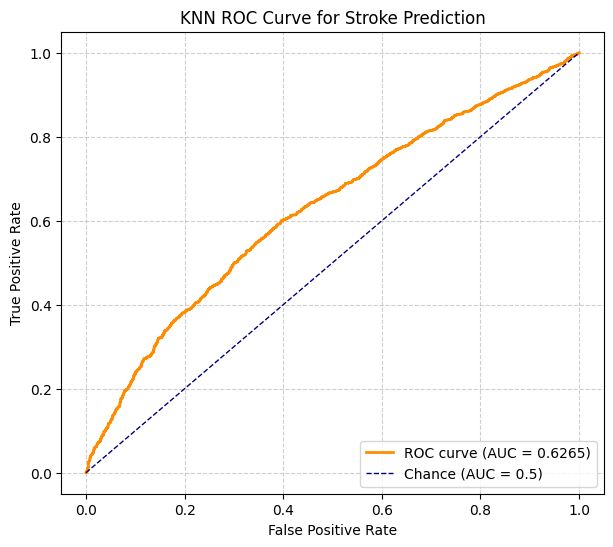

In [294]:
#     ---- need a check ----

# احتمالات الكلاس 1 فقط
y_score_knn = lr.predict_proba(X_test)[:, 1]

# حساب FPR و TPR و AUC
fpr, tpr, _ = roc_curve(y_test, y_score_knn)
roc_auc = roc_auc_score(y_test, y_score_knn)

# رسم منحنى ROC
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Chance (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN ROC Curve for Stroke Prediction')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# PCA graph to be deleted -> show it to the instructor

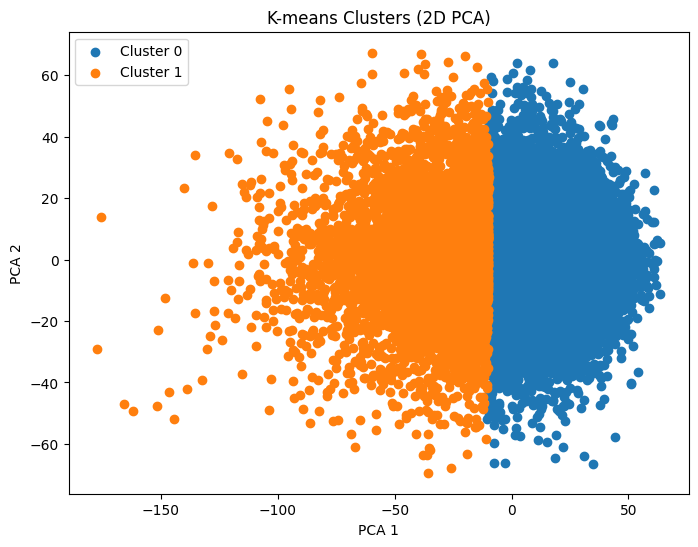

In [295]:
from sklearn.decomposition import PCA


# X : مصفوفة الصور flattened (num_images, 16384)

# ---- PCA لتقليل الأبعاد ----
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# ---- K-means ----
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_pca)

# ---- Scatter plot ----
plt.figure(figsize=(8,6))

# لون كل cluster بلون مختلف
for cluster in np.unique(labels):
    plt.scatter(
        X_pca[labels == cluster, 0], 
        X_pca[labels == cluster, 1], 
        label=f'Cluster {cluster}'
    )

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('K-means Clusters (2D PCA)')
plt.legend()
plt.show()
